In [15]:
import os
import os.path as osp
import cv2

import numpy as np
from PIL import Image
from torch.utils.data import Dataset
from torchvision import transforms
from torch.utils.data import DataLoader

# Data Processing

## The Proposed Strategies

1. FCN
2. Dividing the input image into grids.
3. Random sampling of image patches

## **(!) The Text i'll be using from Research Paper**

# FCN

**We can deploy a fully convolutional network (FCN) to generate the dense representation   $$ U \in \mathbb{R}^{H \times W \times C} $$   of an image, where \( H \) and \( W \) denote the spatial size of the feature map and \( C \) is the feature dimension.   Each image representation contains a collection of local feature vors   $$ \{u_1, u_2, \ldots _{HW} $$   and each vector \( u_i \) can be seen as node in the set. Thus, the dissimilarity of two images can be represented as the optimal mat hing cost between two sets o**
two sets o


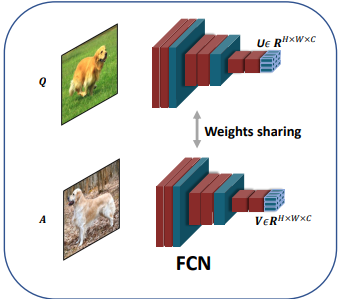f vectors.s. vectors.

In [12]:
class FCNLoader(Dataset): 
    def __init__(self, setname):
        dir = '/kaggle/input/fc100dataset/FC100 Dataset'
        if setname == 'train':
            path = osp.join(dir, 'train/train')
            label_list = os.listdir(path)
        elif setname == 'val':
            path = osp.join(dir, 'val/val')
            label_list = os.listdir(path)
        elif setname == 'test':
            path = osp.join(dir, 'test/test')
            label_list = os.listdir(path)
        else:
            raise ValueError('unknown setname..')

        data = []
        label = []
        folders = [osp.join(path, label) for label in label_list if osp.isdir(osp.join(path, label))]
        print(folders[:10])
        for idx, this_folder in enumerate(folders):
            this_folder_images = os.listdir(this_folder)
            for image_path in this_folder_images:
                data.append(osp.join(this_folder, image_path))
                label.append(idx)

        self.data = data
        self.label = label
        self.num_class = len(set(label)) 

       # transformation
        if setname == 'train':
            image_size = 84
            self.transform = transforms.Compose([
                transforms.RandomResizedCrop(image_size),
                transforms.RandomHorizontalFlip(),
                transforms.ToTensor(),
                transforms.Normalize(np.array([x / 255.0 for x in [125.3, 123.0, 113.9]]),
                                     np.array([x / 255.0 for x in [63.0, 62.1, 66.7]]))])
        else:
            image_size = 84
            self.transform = transforms.Compose([
                transforms.Resize([92, 92]),
                transforms.CenterCrop(image_size),
                transforms.ToTensor(),
                transforms.Normalize(np.array([x / 255.0 for x in [125.3, 123.0, 113.9]]),
                                     np.array([x / 255.0 for x in [63.0, 62.1, 66.7]]))])

    
    def __len__(self):
        return len(self.data)

    def __getitem__(self, i):
        path, label = self.data[i], self.label[i]
        image = self.transform(Image.open(path).convert('RGB'))
        return image, label

In [13]:
tds = CustomDataset(setname='train')
tlr = DataLoader(tds, batch_size=16, shuffle=True)

for images, labels in tlr:
    print(images.shape, labels)
    break

['/kaggle/input/fc100dataset/FC100 Dataset/train/train/n00000013', '/kaggle/input/fc100dataset/FC100 Dataset/train/train/n00000054', '/kaggle/input/fc100dataset/FC100 Dataset/train/train/n00000093', '/kaggle/input/fc100dataset/FC100 Dataset/train/train/n00000000', '/kaggle/input/fc100dataset/FC100 Dataset/train/train/n00000040', '/kaggle/input/fc100dataset/FC100 Dataset/train/train/n00000062', '/kaggle/input/fc100dataset/FC100 Dataset/train/train/n00000067', '/kaggle/input/fc100dataset/FC100 Dataset/train/train/n00000052', '/kaggle/input/fc100dataset/FC100 Dataset/train/train/n00000053', '/kaggle/input/fc100dataset/FC100 Dataset/train/train/n00000047']
torch.Size([16, 3, 84, 84]) tensor([45,  2, 22, 36, 31, 37, 28, 37, 42, 58, 40,  7, 24, 18,  7, 25])


# Dividing the input image into grids.

**We crop the 
image evenly into an H × W grid before feeding it to the
CNN, and each image patch in the grid cell is encoded by
the CNN individually and generates a feature vector. The
feature vectors generated by all the patches constitute the
embedding set of an i**mage

In [8]:
def get_grid_centers(image_size, num_grid):
    grid_size = image_size // num_grid 
    centers = []
    
    for i in range(num_grid):
        center = (i * grid_size) + (grid_size // 2)  
        centers.append(center)
    
    return centers

### ====< example for a 2x2 grid > ====== ###

image_size = 84  
num_grid = 3   

centers = get_grid_centers(image_size, num_grid)
print("Grid Centers:", centers)

Grid Centers: [14, 42, 70]


In [11]:

image_size = 82  
num_grid = 3  ## 3x3 grid
grid_size = image_size // num_grid  ## each grid cell size

### centers of the grid cells
centers = [grid_size * i + grid_size // 2 for i in range(num_grid)]
print(centers)

[13, 40, 67]


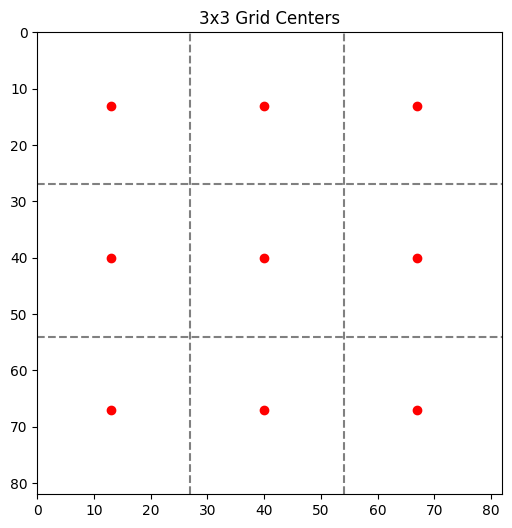

In [12]:
plt.figure(figsize=(6, 6))

for i in range(1, num_grid):
    plt.axhline(y=i * grid_size, color='gray', linestyle='--')  
    plt.axvline(x=i * grid_size, color='gray', linestyle='--')  

for y in centers:
    for x in centers:
        plt.plot(x, y, 'ro')  

plt.xlim(0, image_size)
plt.ylim(0, image_size)

plt.gca().invert_yaxis()

plt.title(f"{num_grid}x{num_grid} Grid Centers")
plt.show()

When dividing the image into a grid, the center of each grid cell is a reference point. From these centers, we extract patches of the image. The idea is that you don't just take random patches instead... you extract patches based on the locations of these centers.so in this way the patches are evenly distributed and focused on specific parts of the image

Basically (non overlapping patches)

In [ ]:
class GridLoader(Dataset):
    def __init__(self, setname):
        dir = '/kaggle/input/fc100dataset/FC100 Dataset'
        if setname == 'train':
            path = osp.join(dir, 'train/train')
            label_list = os.listdir(path)
        elif setname == 'val':
            path = osp.join(dir, 'val/val')
            label_list = os.listdir(path)
        elif setname == 'test':
            path = osp.join(dir, 'test/test')
            label_list = os.listdir(path)
        else:
            raise ValueError('unknown setname..')

        self.setname = setname
        self.wnids = label_list

        ## default values
        self.patch_list = getattr(args, 'patch_list', [2, 3])
        self.patch_ratio = getattr(args, 'patch_ratio', 2)

        ## collect image path and corresponding labels
        self.data, self.labels = [], []
        for idx, label in enumerate(self.wnids):
            label_path = os.path.join(path, abs.wnids)
            if os.path.idir(label_path):
                for img_name in os.listdir(label_path):
                    self.data.append(os.path.join(label_path, img_name))
                    self.label.append(idx)

        self.num_classes = len(set(self.labels))
        # image transformation 
        self.transform = transforms.Compose([
            transforms.Resize((84, 84)),  # Resize image to 84x84
            transforms.ToTensor(),
            transforms.Normalize(mean=[x / 255.0 for x in [125.3, 123.0, 113.9]], 
                                 std=[x / 255.0 for x in [63.0, 62.1, 66.7]])
        ])
        def __len__(self):
            return len(self.data)

        def get_locations(self, size, ratio, n_grids):
            raw_grid_size = size // num_grid
            enlarged_grid_size = int(raw_grid_size * ratio)
            center_location = raw_grid_size // 2
    
            locations = []
            for i in range(num_grid):
                start = max(0, center_location - enlarged_grid_size // 2)
                end = min(size, center_location + enlarged_grid_size // 2)
                locations.append((start, end))
                center_location += raw_grid_size
            
            return locations

         def get_patches(self, image, num_patch):
             if self.setname == 'val' or self.setname == 'test':
                num_grid = num_patch
                grid_ratio = self.patch_ratio

            elif self.setname == 'train':
                num_grid = num_patch
                grid_ratio = 1 + 2 * random.random()
    
    
            else:
                raise ValueError('Unkown set')

        
             w, h = image.size
             grid_w = self.get_locations(w, self.patch_ratio, num_patch)
             grid_h = self.get_locations(h, self.patch_ratio, num_patch)

             patches = []
             for i in range(num_patch):
                 for j in range(num_patch):
                     patch = image.crop((grid_w[j][0], grid_h[i][0], grid_w[j][1], grid_h[i][1]))
                     patches.append(self.transform(patch))
                     
             return patches

          def __getitem__(self, i):
              path, label = self.data[i], self.label[i]
              image = Image.open(path).convert('RGB')


              patch_list = []
              for num_patch in self.patch_size:
                  patches = self.get_patches(image, num_patch)
                  patch_list.extend(patches)
              patch_list = torch.stack(patch_list, dim=0)
              return patch_list, label

# Random sampling of image patches
**Instead of generating the image patches by grids, here we randomly sample M
patches in the images with different sizes and aspect ratios.
The randomly sampled patches are then re-scaled to the
same input size and are encoded by CNNs. The embeddings
of these sampled patches make up the embedding set of an
image.
We denote our networks adopting the three strategies above
by DeepEMD-FCN, DeepEMD-Grid, and DeepEMD-Sampling,
respectively. As the size of the grid in DeepEMD-Grid and
the number of patches in DeepEMD-Sampling are hyperparameters in our network, we conduct various experiments to investigate the influence of these parameters in
Section 5.3. We also investigate pyramid structures on the
image level and the feature level to capture local representations at multiple scales, illustrated in Fig. 3. Specifically,
we add a feature pyramid structure to DeepEMD-FCN and
an image pyramid structure to DeepEMD-Grid. The feature
pyramid applies the RoI pooling to the feature maps generated by the FCN, and the resulting feature vectors together
with the raw feature vectors constitute the embedding set.
For the image pyramid, we simply crop the patches according to different grid sizes and send all patches to the CNN
to generate t**he embedding set.


In [ ]:
class RSDataLoader(Dataset):

    def __init__(self, setname, args=None):
        DATASET_DIR = os.path.join(args.data_dir, 'FC100/')
        if setname == 'train':
            THE_PATH = osp.join(DATASET_DIR, 'train')
            label_list = os.listdir(THE_PATH)
        elif setname == 'test':
            THE_PATH = osp.join(DATASET_DIR, 'test')
            label_list = os.listdir(THE_PATH)
        elif setname == 'val':
            THE_PATH = osp.join(DATASET_DIR, 'val')
            label_list = os.listdir(THE_PATH)
        else:
            raise ValueError('Wrong setname.')
        self.wnids = label_list

        data = []
        label = []

        if 'num_patch' not in vars(args).keys():
            print('no num_patch parameter, set as default: 9')
            self.num_patch = 9
        else:
            self.num_patch = args.num_patch

        folders = [osp.join(THE_PATH, label) for label in label_list if os.path.isdir(osp.join(THE_PATH, label))]

        for idx, this_folder in enumerate(folders):
            this_folder_images = os.listdir(this_folder)
            for image_path in this_folder_images:
                data.append(osp.join(this_folder, image_path))
                label.append(idx)
        self.data = data
        self.label = label
        self.num_class = len(set(label))

        image_size = 84
        self.transform = transforms.Compose([
            transforms.RandomResizedCrop(image_size), ### M
            transforms.RandomHorizontalFlip(),
            transforms.ToTensor(),
            transforms.Normalize(np.array([x / 255.0 for x in [125.3, 123.0, 113.9]]),
                                 np.array([x / 255.0 for x in [63.0, 62.1, 66.7]]))
        ])

    def __len__(self):
        return len(self.data)

    def __getitem__(self, i):
        path, label = self.data[i], self.label[i]
        patch_list = []
        for _ in range(self.num_patch):
            patch_list.append(self.transform(Image.open(path).convert('RGB'))) 
        patch_list = torch.stack(patch_list, dim=0)
        return patch_list, label